In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
RANDOM_SEED = 41

In [2]:
iris = load_iris() 
features = iris.data

data = pd.DataFrame(features, columns = iris.feature_names)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
X = data.iloc[:, [0, 2]]
y = iris.target
X.shape, y.shape

((150, 2), (150,))

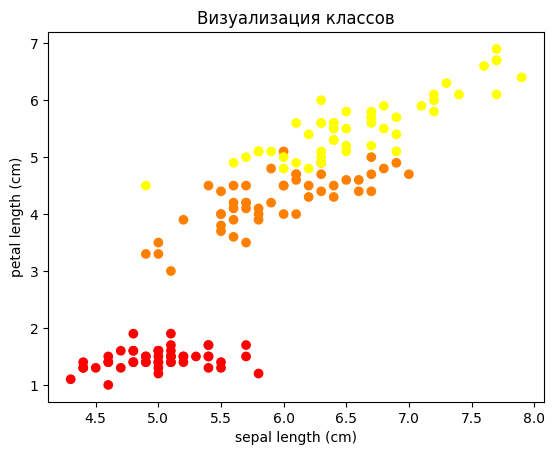

In [4]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

y_pred = knn.predict(X_scaled)

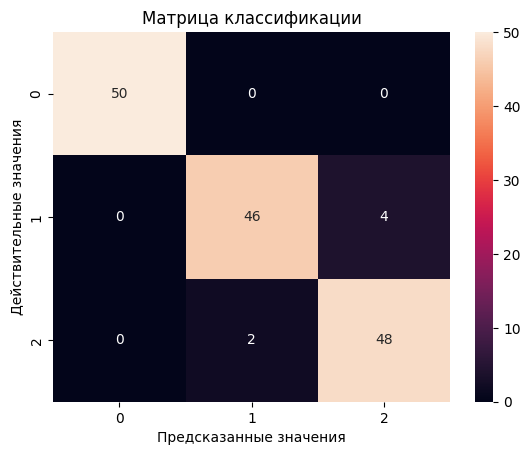

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.title("Матрица классификации")
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt ='d')
plt.ylabel('Действительные значения')
plt.xlabel('Предсказанные значения')
plt.show()

In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.96      0.94        48
           2       0.96      0.92      0.94        52

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [10]:
X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)

XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T
XX_scaled = scaler.transform(XX)
Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


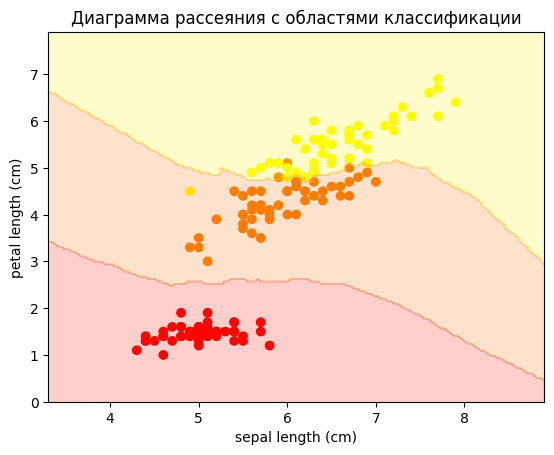

In [11]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Диаграмма рассеяния с областями классификации")
plt.show()

In [12]:
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)
knn.predict(observation_new_scaled)

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([2])

In [13]:
knn.predict_proba(observation_new_scaled)

array([[0., 0., 1.]])

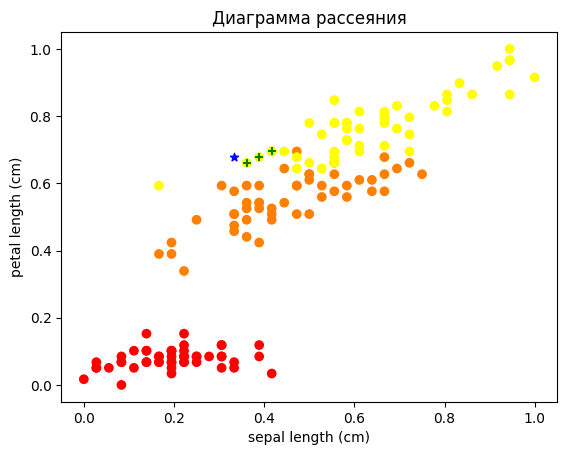

In [14]:
distances, indices = knn.kneighbors(observation_new_scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', color='b')

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

# EXTRA TASKS
# 1

prediction for [[5.5, 5]] -> [2]
distances to 3 nearest: [0.03254042 0.05555556 0.08503951]
indices of neighbours: [121 113 142]
coordinates of neighbours (original space):
     sepal length (cm)  petal length (cm)
121                5.6                4.9
113                5.7                5.0
142                5.8                5.1


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


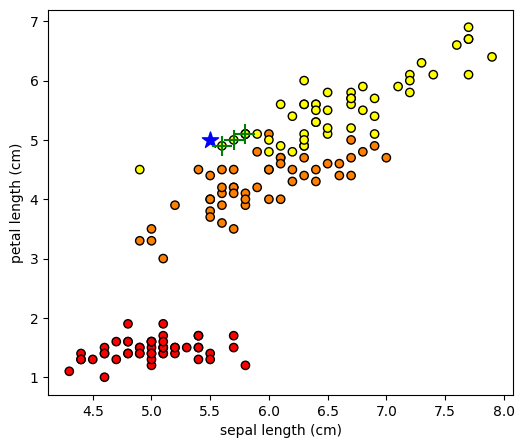

In [16]:
# weird task
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)

pred = knn.predict(observation_new_scaled)
print("prediction for", observation_new, "->", pred)

distances, indices = knn.kneighbors(observation_new_scaled,
                                    n_neighbors=3)
print("distances to 3 nearest:", distances[0])
print("indices of neighbours:", indices[0])
print("coordinates of neighbours (original space):")
print(X.iloc[indices[0]])

plt.figure(figsize=(6, 5))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, cmap='autumn', edgecolor='k')

plt.scatter(observation_new[0][0], observation_new[0][1],
            marker='*', s=150, color='blue', label='new point')

neigh_coords = X.iloc[indices[0]]
plt.scatter(neigh_coords.iloc[:,0], neigh_coords.iloc[:,1],
            marker='+', s=200, color='green', label='3 nearest neighbors')

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

# 2

In [20]:
from sklearn.metrics import accuracy_score
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 30, 100]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y)
    y_pred = knn.predict(X_scaled)
    print(f"Accuracy for k={k}:\n")
    print(accuracy_score(y_pred, y))

Accuracy for k=1:

0.9933333333333333
Accuracy for k=3:

0.96
Accuracy for k=5:

0.9533333333333334
Accuracy for k=7:

0.96
Accuracy for k=9:

0.9466666666666667
Accuracy for k=11:

0.9533333333333334
Accuracy for k=13:

0.9666666666666667
Accuracy for k=15:

0.9533333333333334
Accuracy for k=30:

0.9066666666666666
Accuracy for k=100:

0.6333333333333333


# 3

prediction for [[5.5, 5]] -> [1]
distances to 3 nearest: [0.03254042 0.05555556 0.08503951]
indices of neighbours: [121 113 101]
coordinates of neighbours (original space):
     sepal length (cm)  petal length (cm)
121                5.6                4.9
113                5.7                5.0
101                5.8                5.1


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


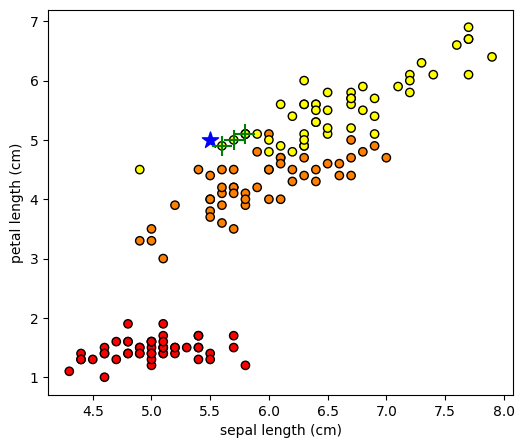

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


prediction for [[1, 0.5]] -> [0]
distances to 3 nearest: [0.92229043 0.95412831 0.95412831]
indices of neighbours: [13 38 42]
coordinates of neighbours (original space):
    sepal length (cm)  petal length (cm)
13                4.3                1.1
38                4.4                1.3
42                4.4                1.3


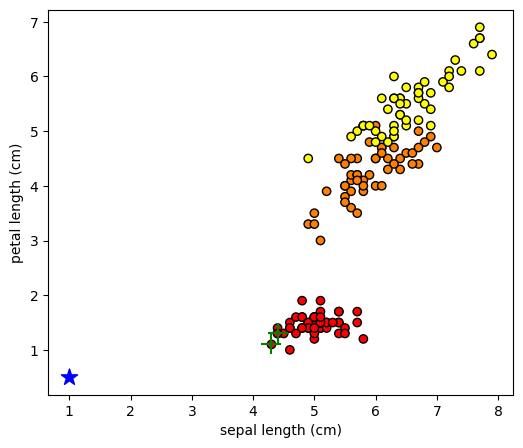

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


prediction for [[7, 3]] -> [1]
distances to 3 nearest: [0.25149573 0.262014   0.2762735 ]
indices of neighbours: [65 75 74]
coordinates of neighbours (original space):
    sepal length (cm)  petal length (cm)
65                6.7                4.4
75                6.6                4.4
74                6.4                4.3


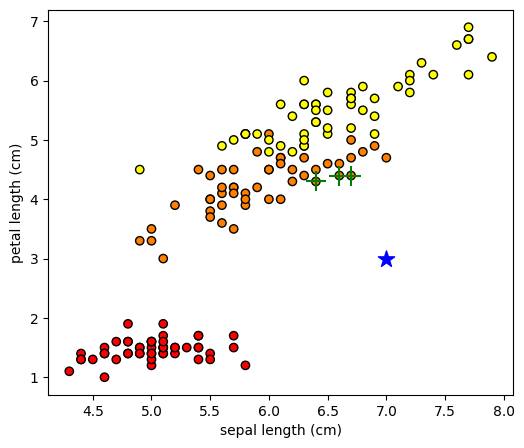

In [23]:
observation_new_points = [[5.5, 5], [1, 0.5], [7, 3]]
for obs in observation_new_points:
    observation_new = [obs, ]
    observation_new_scaled = scaler.transform(observation_new)

    pred = knn.predict(observation_new_scaled)
    print("prediction for", observation_new, "->", pred)

    distances, indices = knn.kneighbors(observation_new_scaled,
                                        n_neighbors=3)
    print("distances to 3 nearest:", distances[0])
    print("indices of neighbours:", indices[0])
    print("coordinates of neighbours (original space):")
    print(X.iloc[indices[0]])

    plt.figure(figsize=(6, 5))
    plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, cmap='autumn', edgecolor='k')

    plt.scatter(observation_new[0][0], observation_new[0][1],
                marker='*', s=150, color='blue', label='new point')

    neigh_coords = X.iloc[indices[0]]
    plt.scatter(neigh_coords.iloc[:,0], neigh_coords.iloc[:,1],
                marker='+', s=200, color='green', label='3 nearest neighbors')

    plt.xlabel('sepal length (cm)')
    plt.ylabel('petal length (cm)')
    plt.show()

# 4


metric = euclidean
distances: [0.03254042 0.05555556 0.08503951]
indices : [121 113 142]
neighbors (orig):
     sepal length (cm)  petal length (cm)
121                5.6                4.9
113                5.7                5.0
142                5.8                5.1


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


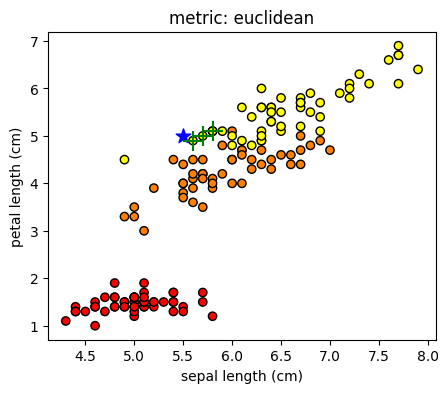


metric = manhattan
distances: [0.04472693 0.05555556 0.10028249]
indices : [121 113 142]
neighbors (orig):
     sepal length (cm)  petal length (cm)
121                5.6                4.9
113                5.7                5.0
142                5.8                5.1


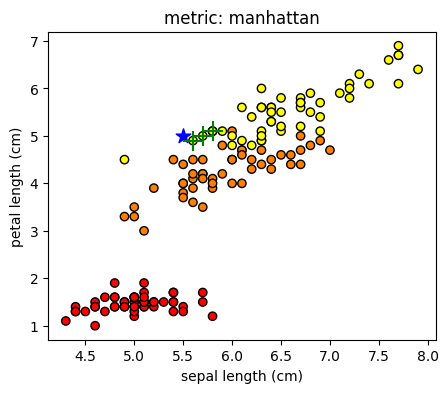


metric = chebyshev
distances: [0.02777778 0.05555556 0.08333333]
indices : [121 113 142]
neighbors (orig):
     sepal length (cm)  petal length (cm)
121                5.6                4.9
113                5.7                5.0
142                5.8                5.1


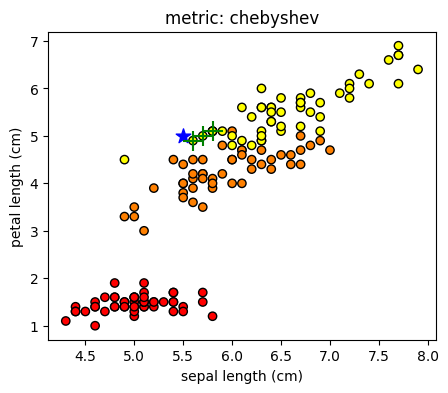


metric = minkowski
distances: [0.03254042 0.05555556 0.08503951]
indices : [121 113 142]
neighbors (orig):
     sepal length (cm)  petal length (cm)
121                5.6                4.9
113                5.7                5.0
142                5.8                5.1


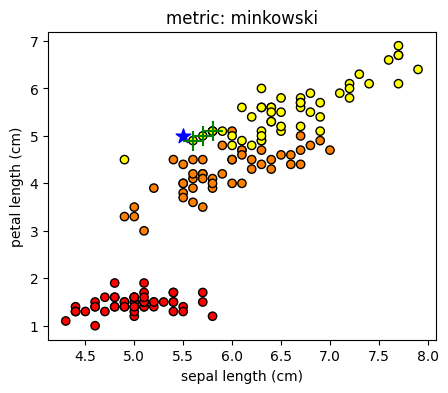

In [25]:
observation_new = [[5.5, 5]]
obs_scaled = scaler.transform(observation_new)

metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn.fit(X_scaled, y)

    dist, inds = knn.kneighbors(obs_scaled)
    print(f"\nmetric = {metric}")
    print("distances:", dist[0])
    print("indices :", inds[0])
    print("neighbors (orig):")
    print(X.iloc[inds[0]])

    plt.figure(figsize=(5, 4))
    plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, cmap='autumn', edgecolor='k')
    plt.scatter(observation_new[0][0], observation_new[0][1],
                marker='*', s=120, color='blue', label='new')
    neigh = X.iloc[inds[0]]
    plt.scatter(neigh.iloc[:,0], neigh.iloc[:,1],
                marker='+', s=200, color='green', label='neighbors')
    plt.title(f"metric: {metric}")
    plt.xlabel('sepal length (cm)')
    plt.ylabel('petal length (cm)')
    plt.show()

# 5

In [27]:
# ok?
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 30, 100]
for k in k_values:
    knn_full = KNeighborsClassifier(n_neighbors=3)
    knn_full.fit(X_scaled, y)

    y_pred_full = knn_full.predict(X_scaled)
    acc = accuracy_score(y, y_pred_full)

    print("accuracy on full data: at k=", k, ", acc=", acc)

accuracy on full data: at k= 1 , acc= 0.96
accuracy on full data: at k= 3 , acc= 0.96
accuracy on full data: at k= 5 , acc= 0.96
accuracy on full data: at k= 7 , acc= 0.96
accuracy on full data: at k= 9 , acc= 0.96
accuracy on full data: at k= 11 , acc= 0.96
accuracy on full data: at k= 13 , acc= 0.96
accuracy on full data: at k= 15 , acc= 0.96
accuracy on full data: at k= 30 , acc= 0.96
accuracy on full data: at k= 100 , acc= 0.96


# 6

In [29]:
weights = ['uniform', 'distance']
for weight in weights:
    knn_full = KNeighborsClassifier(n_neighbors=3, weights=weight)
    knn_full.fit(X_scaled, y)

    y_pred_full = knn_full.predict(X_scaled)
    acc = accuracy_score(y, y_pred_full)

    print("accuracy with weights=", weight, ":", acc)

accuracy with weights= uniform : 0.96
accuracy with weights= distance : 0.9933333333333333


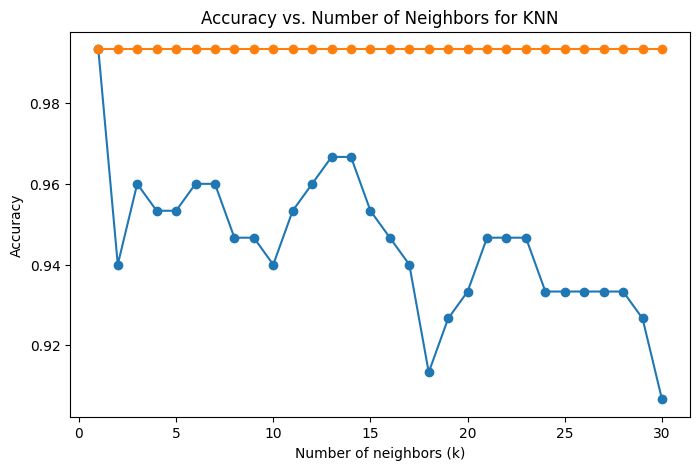

In [ ]:
ks = list(range(1, 31))
acc_uniform = []
acc_distance = []
for k in ks:
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_scaled, y)
    y_pred_uniform = knn_uniform.predict(X_scaled)
    acc_uniform.append(accuracy_score(y, y_pred_uniform))

    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_distance.fit(X_scaled, y)
    y_pred_distance = knn_distance.predict(X_scaled)
    acc_distance.append(accuracy_score(y, y_pred_distance))
plt.figure(figsize=(8, 5))
plt.plot(ks, acc_uniform, label='uniform weights', marker='o')
plt.plot(ks, acc_distance, label='distance weights', marker='o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Accuracy')
plt.show()

# 8

features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
MSE: 3727.014761041366
R²  : 0.38231963179400363


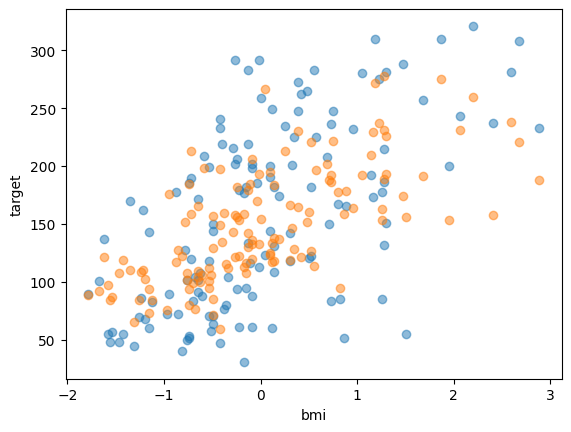

In [31]:
from sklearn import datasets
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# diabeter
data = datasets.load_diabetes()
X, y = data.data, data.target
print("features:", data.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_SEED)

knn_reg = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn_reg.fit(X_train, y_train)

y_pred = knn_reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

import matplotlib.pyplot as plt
feat = 2        # pick any column to plot
plt.scatter(X_test[:, feat], y_test, alpha=0.5, label='true')
plt.scatter(X_test[:, feat], y_pred, alpha=0.5, label='pred')
plt.xlabel(data.feature_names[feat])
plt.ylabel('target')
plt.show()